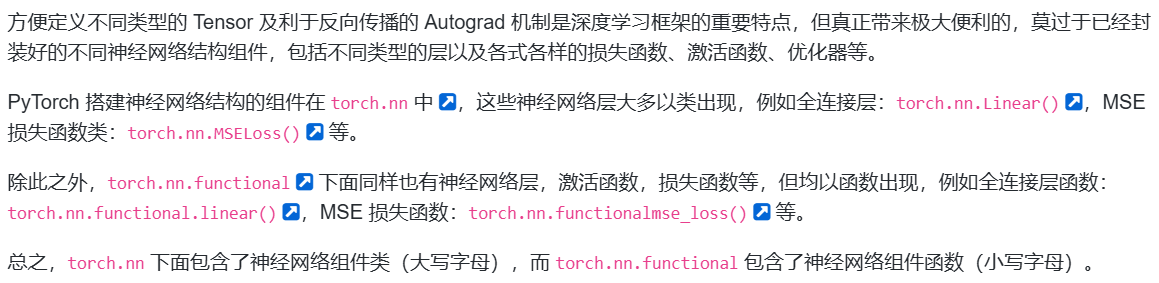

## MNIST ##

In [2]:
import torchvision

# 加载训练数据，参数 train=True，供 60000 条
train = torchvision.datasets.MNIST(
    root='.', train=True, transform=torchvision.transforms.ToTensor(), download=True)
# 加载测试数据，参数 train=False，供 10000 条
test = torchvision.datasets.MNIST(
    root='.', train=False, transform=torchvision.transforms.ToTensor(), download=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [03:47<00:00, 43.6kB/s]


Extracting .\MNIST\raw\train-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:01<00:00, 25.3kB/s]


Extracting .\MNIST\raw\train-labels-idx1-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:28<00:00, 57.2kB/s]


Extracting .\MNIST\raw\t10k-images-idx3-ubyte.gz to .\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 1.76MB/s]

Extracting .\MNIST\raw\t10k-labels-idx1-ubyte.gz to .\MNIST\raw



上面的代码中，transform=torchvision.transforms.ToTensor()  是利用了 torchvision 提供的 transforms 直接将原 NumPy 数组转换为 PyTorch 张量

In [3]:
train.data.shape, train.targets.shape, test.data.shape, test.targets.shape

(torch.Size([60000, 28, 28]),
 torch.Size([60000]),
 torch.Size([10000, 28, 28]),
 torch.Size([10000]))

我们还需要使用 PyTorch 提供的一个组件对数据进行封装。torch.utils.data.DataLoader  是 PyTorch 提供的及其常用的数据加载器，它可以将数据集封装成迭代器以方便我们后续进行小批量加载，数据打乱等操作。数据加载器准备好之后，后续只需要通过 for 循环来使用即可。

In [ ]:
import torch

# 训练数据打乱，使用 64 小批量
train_loader = torch.utils.data.DataLoader(dataset=train,
                                           batch_size=64, shuffle=True)
# 测试数据无需打乱，使用 64 小批量
test_loader = torch.utils.data.DataLoader(dataset=test,
                                          batch_size=64, shuffle=False)

train_loader, test_loader

(<torch.utils.data.dataloader.DataLoader at 0x1a36ac063c0>,
 <torch.utils.data.dataloader.DataLoader at 0x1a360f4f1a0>)

在 PyTorch 的 DataLoader 类中，shuffle 参数是一个可选的布尔值（Optional[bool] = None），用于控制数据加载时是否随机打乱样本顺序。如果设置为 True，则在每个训练周期（epoch）开始时重新洗牌数据集，以提高模型的泛化能力；如果为 False 或 None，则保持原始顺序。默认情况下，对于 map-style 数据集，如果未指定 sampler，则 shuffle 默认为 False。

接下来，我们学习 PyTorch 构建神经网络的经典方法，也是官方推荐使用的一种方法。  

首先，torch.nn 中的一个基础类 torch.nn.Module 。该类是 PyTorch 中所有神经网络的基类，它既可以表示神经网络中的某层，也可以表示若干层的神经网络。torch.nn 中的各个类实际上就是由 torch.nn.Modules 继承而拓展。所以，在实际使用中，我们可以继承nn.Module，撰写自定义网络层。

所以，当我们搭建神经网络时，也需要继承 torch.nn.Module。我们准备搭建一个包含两个隐含层的全连接网络。   
输入（784） → 全连接层 1 （784, 512）→ 全连接层 2 （512, 128）→ 输出（10）

In [5]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 512)  # 784 是因为训练是我们会把 28*28 展平
        self.fc2 = nn.Linear(512, 128)  # 使用 nn 类初始化线性层（全连接层）
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))  # 直接使用 relu 函数，也可以自己初始化一个 nn 下面的 Relu 类使用
        x = F.relu(self.fc2(x))
        x = self.fc3(x)  # 输出层一般不激活
        return x

我们定义了新的神经网络结构类 Net()，并使用 nn.Linear 组合了 3 个线性层（全连接层）。前向传播过程中，代码使用了 PyTorch 中常用的函数模块 torch.nn.functional 提供的 RELU 激活函数，实际上你也可以通过实例化 nn.Relu 来达到同样的效果。

In [6]:
# 实例化自定义神经网络类：
model = Net()
model

Net(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)

In [7]:
# PyTorch 的好处在于你可以初始化一个 784 长度的随机值样本传入网络，测试一下输出：
model(torch.randn(1, 784))

tensor([[-0.0293, -0.0691,  0.0063, -0.0179, -0.1327, -0.1324,  0.0191,  0.0666,
          0.0088,  0.0067]], grad_fn=<AddmmBackward0>)

In [8]:
# 定义损失函数，优化器以及开始训练
loss_fn = nn.CrossEntropyLoss()  # 交叉熵损失函数
opt = torch.optim.Adam(model.parameters(), lr=0.002)  # Adam 优化器

这里，我们选择了十分常用的交叉熵损失函数 nn.CrossEntropyLoss ，以及 Adam 优化器 torch.optim.Adam 。值得注意的是，PyTorch 中优化器需传入模型的参数 model.parameters()，这是 PyTorch 的一个使用特性。

In [9]:
def fit(epochs, model, opt):
    print("Start training, please be patient.")
    # 全数据集迭代 epochs 次
    for epoch in range(epochs):
        # 从数据加载器中读取 Batch 数据开始训练
        for i, (images, labels) in enumerate(train_loader):
            images = images.reshape(-1, 28*28)  # 对特征数据展平，变成 784
            labels = labels  # 真实标签
            outputs = model(images)  # 前向传播
            loss = loss_fn(outputs, labels)  # 传入模型输出和真实标签
            opt.zero_grad()  # 优化器梯度清零，否则会累计
            loss.backward()  # 从最后 loss 开始反向传播
            opt.step()  # 优化器迭代
            # 自定义训练输出样式
            if (i+1) % 100 == 0:
                print('Epoch [{}/{}], Batch [{}/{}], Train loss: {:.3f}'
                      .format(epoch+1, epochs, i+1, len(train_loader), loss.item()))
        # 每个 Epoch 执行一次测试
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.reshape(-1, 28*28)
            labels = labels
            outputs = model(images)
            # 得到输出最大值 _ 及其索引 predicted
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()  # 如果预测结果和真实值相等则计数 +1
            total += labels.size(0)  # 总测试样本数据计数
        print('============ Test accuracy: {:.3f} ============='.format(
            correct / total))

In [ ]:
fit(epochs=1, model=model, opt=opt)  # 训练 1 个 Epoch，预计持续 10s

Start training, please be patient.
Epoch [1/1], Batch [100/938], Train loss: 0.312
Epoch [1/1], Batch [200/938], Train loss: 0.113
Epoch [1/1], Batch [300/938], Train loss: 0.131
Epoch [1/1], Batch [400/938], Train loss: 0.109
Epoch [1/1], Batch [500/938], Train loss: 0.058
Epoch [1/1], Batch [600/938], Train loss: 0.172
Epoch [1/1], Batch [700/938], Train loss: 0.078
Epoch [1/1], Batch [800/938], Train loss: 0.206
Epoch [1/1], Batch [900/938], Train loss: 0.096
============ Test accuracy: 0.966 =============


opt.zero_grad() 这步非常关键。由于 PyTorch 设计时梯度会累计，所以我们需要手动清零以实现传入一个 Batch，计算梯度，然后更新参数，从而不会因为前面的梯度累计影响后面的参数更新。但 PyTorch 这样设计也是有原因的，比如当我们想提升 Batch 的大小而硬件又无法处理较多数据时，就可以通过梯度累积机制，等待传入多个 Batch 后再更新参数并执行清零，这就给了开发更多的灵活性。同时，后续循环神经网络中也可能利用到这个特性

## Sequential容器结构 ##

In [12]:
model_s = nn.Sequential(
    nn.Linear(784, 512),  # 线性类
    nn.ReLU(),  # 激活函数类
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, 10),
)

model_s  # 查看网络结构

Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

In [13]:
opt_s = torch.optim.Adam(model_s.parameters(), lr=0.002)  # Adam 优化器
fit(epochs=1, model=model_s, opt=opt_s)  # 训练 1 个 Epoch

Start training, please be patient.
Epoch [1/1], Batch [100/938], Train loss: 0.308
Epoch [1/1], Batch [200/938], Train loss: 0.303
Epoch [1/1], Batch [300/938], Train loss: 0.058
Epoch [1/1], Batch [400/938], Train loss: 0.227
Epoch [1/1], Batch [500/938], Train loss: 0.117
Epoch [1/1], Batch [600/938], Train loss: 0.056
Epoch [1/1], Batch [700/938], Train loss: 0.230
Epoch [1/1], Batch [800/938], Train loss: 0.094
Epoch [1/1], Batch [900/938], Train loss: 0.226
============ Test accuracy: 0.961 =============


## GPU加速训练 ##

图形处理器 GPU 是深度学习加速训练的重要硬件。当我们使用 TensorFlow 构建神经网络时，一般会自动调用 GPU 而无需修改代码 。不过，PyTorch 使用 GPU 加速会麻烦一些，我们需要将数据张量和模型都转化为 CUDA 类型 。为了方便大家在使用 PyTorch 时调用 GPU，下面给出一般流程用于参考。

In [14]:
torch.cuda.is_available()

False

In [15]:
# 如果 GPU 可用则使用 CUDA 加速，否则使用 CPU 设备计算
dev = torch.device(
    "cuda") if torch.cuda.is_available() else torch.device("cpu")
dev

device(type='cpu')

然后修改代码，数据和模型后面添加 .to(dev)，这样 PyTorch 就可以自动判断是否使用 GPU 加速了。首先是对从 DataLoader 中加载出来的每一批次数据后添加 .to(dev)。我们沿用 fit(epochs, model, opt) 中的代码。

In [16]:
def fit(epochs, model, opt):
    print("Start training, please be patient.")
    for epoch in range(epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.reshape(-1, 28*28).to(dev)  # 添加 .to(dev)
            labels = labels.to(dev)  # 添加 .to(dev)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            opt.zero_grad()
            loss.backward()
            opt.step()
            if (i+1) % 100 == 0:
                print('Epoch [{}/{}], Batch [{}/{}], Train loss: {:.3f}'
                      .format(epoch+1, epochs, i+1, len(train_loader), loss.item()))
        correct = 0
        total = 0
        for images, labels in test_loader:
            images = images.reshape(-1, 28*28).to(dev)  # 添加 .to(dev)
            labels = labels.to(dev)  # 添加 .to(dev)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        print('============ Test accuracy: {:.3f} ============='.format(
            correct / total))

接下来，给模型添加 .to(dev)，使得模型可以自动判断是否使用 CUDA 加速。请注意，由于优化器中传入了模型的参数，而该参数可能会因为 GPU 变更为 CUDA 类型，所以我们需要重新执行优化器代码防止数据类型不一致而报错。

In [17]:
model_s.to(dev)
opt_s = torch.optim.Adam(model_s.parameters(), lr=0.002)

In [18]:
fit(epochs=1, model=model_s, opt=opt_s)  # 训练 1 个 Epoch

Start training, please be patient.
Epoch [1/1], Batch [100/938], Train loss: 0.134
Epoch [1/1], Batch [200/938], Train loss: 0.074
Epoch [1/1], Batch [300/938], Train loss: 0.140
Epoch [1/1], Batch [400/938], Train loss: 0.015
Epoch [1/1], Batch [500/938], Train loss: 0.030
Epoch [1/1], Batch [600/938], Train loss: 0.056
Epoch [1/1], Batch [700/938], Train loss: 0.100
Epoch [1/1], Batch [800/938], Train loss: 0.080
Epoch [1/1], Batch [900/938], Train loss: 0.063
============ Test accuracy: 0.969 =============


## 模型保存与推理 ##


In [19]:
# 我们同样可以保存 PyTorch 模型以用于推理。直接使用 torch.save  将模型存在 .pt 文件即可。
torch.save(model_s, './model_s.pt')

In [20]:
# 接下来，使用 torch.load  加载模型即可使用模型进行推理。
model_s = torch.load('./model_s.pt')
model_s

C:\Users\35096\AppData\Local\Temp\ipykernel_31892\2927614127.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_s = torch.load('./model_s.pt')


Sequential(
  (0): Linear(in_features=784, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)

In [25]:
print(model_s.state_dict())

OrderedDict({'0.weight': tensor([[-0.0076,  0.0064, -0.0163,  ...,  0.0263, -0.0197,  0.0135],
        [-0.0187,  0.0121, -0.0331,  ..., -0.0355,  0.0160, -0.0299],
        [ 0.0095,  0.0330, -0.0122,  ..., -0.0309,  0.0187, -0.0073],
        ...,
        [ 0.0339,  0.0330, -0.0109,  ...,  0.0312, -0.0160, -0.0123],
        [ 0.0257,  0.0138,  0.0285,  ..., -0.0183, -0.0183, -0.0172],
        [ 0.0305, -0.0138,  0.0106,  ..., -0.0233,  0.0128, -0.0153]]), '0.bias': tensor([ 1.8858e-02,  5.1033e-02,  8.6851e-02,  1.8076e-02,  2.7096e-02,
         2.3462e-02, -6.8454e-03, -1.4191e-03, -1.1247e-01,  5.1963e-02,
        -5.9259e-03, -3.7726e-02, -5.6213e-02,  3.2510e-02, -2.0670e-02,
        -4.1604e-02, -7.6124e-02,  4.1612e-03,  9.7734e-02,  9.7335e-03,
        -5.7770e-03,  5.0037e-02,  2.3669e-02, -3.0948e-02, -7.5754e-02,
         8.2886e-02, -2.1239e-02, -2.5386e-02, -8.4619e-05,  1.7947e-02,
         3.1187e-02, -8.0855e-02, -7.9134e-02,  2.7327e-02, -1.0223e-01,
        -4.2450e-02

In [26]:
for name, param in model_s.named_parameters():
    print(name, param.shape)
    print(param)

0.weight torch.Size([512, 784])
Parameter containing:
tensor([[-0.0076,  0.0064, -0.0163,  ...,  0.0263, -0.0197,  0.0135],
        [-0.0187,  0.0121, -0.0331,  ..., -0.0355,  0.0160, -0.0299],
        [ 0.0095,  0.0330, -0.0122,  ..., -0.0309,  0.0187, -0.0073],
        ...,
        [ 0.0339,  0.0330, -0.0109,  ...,  0.0312, -0.0160, -0.0123],
        [ 0.0257,  0.0138,  0.0285,  ..., -0.0183, -0.0183, -0.0172],
        [ 0.0305, -0.0138,  0.0106,  ..., -0.0233,  0.0128, -0.0153]],
       requires_grad=True)
0.bias torch.Size([512])
Parameter containing:
tensor([ 1.8858e-02,  5.1033e-02,  8.6851e-02,  1.8076e-02,  2.7096e-02,
         2.3462e-02, -6.8454e-03, -1.4191e-03, -1.1247e-01,  5.1963e-02,
        -5.9259e-03, -3.7726e-02, -5.6213e-02,  3.2510e-02, -2.0670e-02,
        -4.1604e-02, -7.6124e-02,  4.1612e-03,  9.7734e-02,  9.7335e-03,
        -5.7770e-03,  5.0037e-02,  2.3669e-02, -3.0948e-02, -7.5754e-02,
         8.2886e-02, -2.1239e-02, -2.5386e-02, -8.4619e-05,  1.7947e-02,


In [21]:
# 对测试数据第一个样本进行推理，注意将张量类型转换为 FloatTensor
result = model_s(test.data[0].reshape(-1, 28*28).type(torch.FloatTensor).to(dev))
torch.argmax(result)  # 找到输出最大值索引即为预测标签

tensor(7)

In [22]:
test.targets[0]  # 第一个测试数据真实标签

tensor(7)